### Imports e Pré-Processamento de Dados

In [1]:
# Imports dos dados
import numpy as np
import pandas as pd
from datetime import datetime
from feature_eng import split_data, input_h2h_features

In [2]:
# Imports do Modelo
import joblib
import optuna
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error

In [3]:
df_raw = pd.read_csv('../cleaned_data/df_odds.csv', parse_dates=['date'], low_memory=False)

cols_to_save = [
    "event_id","league","date",
    "away_team","away_player","away_score",
    "home_team","home_player","home_score",
    "total_score"
    ]

df_raw = df_raw.sort_values("date").reset_index(drop=True)

df_raw = df_raw[df_raw['league'] == 22614]

In [4]:
train_raw, test_raw = split_data(
    df=df_raw,
    split_date=datetime(2025,8,1),
    date_column='date'
)

train_with_avg, test_with_avg, scaler = input_h2h_features(
    train_raw,
    test_raw,
    return_scaler=True,
    drop_h2h=10
)

### Definições Iniciais para o modelo

In [5]:
features = [
    "avg_h2h_u50",
    "avg_h2h_u5",
    "flag_u5_below_u50",
    "flag_u5_above_u50",
    "flag_u5_same_result",
    "flag_u5_below_u50_std",
    "flag_u5_above_u50_std",

]

### Treinamento do Modelo

In [6]:
X_train = train_with_avg[features]
y_train = train_with_avg['total_score']

X_test = test_with_avg[features]
y_test = test_with_avg['total_score']

X = X_train.values
y = y_train.values

In [7]:
def timeseries_cv_rmse(X, y, params, n_splits=5):
    rmse_scores = []
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for train_index, val_index in tscv.split(X):
        X_tr, X_val = X[train_index], X[val_index]
        y_tr, y_val = y[train_index], y[val_index]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        train_params = {
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "subsample": params["subsample"],
            "colsample_bytree": params["colsample_bytree"],
            "min_child_weight": params["min_child_weight"],
            "gamma": params["gamma"],
            "reg_alpha": params["reg_alpha"],
            "reg_lambda": params["reg_lambda"],
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "seed": 42,
        }

        evals = [(dval, "eval"), (dtrain, "train")]

        bst = xgb.train(
            params=train_params,
            dtrain=dtrain,
            num_boost_round=params["n_estimators"],
            evals=evals,
            early_stopping_rounds=30,
            verbose_eval=False
        )

        y_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration+1))
        rmse = root_mean_squared_error(y_val, y_pred)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
    }

    return timeseries_cv_rmse(X, y, params, n_splits=10)

In [8]:
# Rodar o Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)


print("Melhores parâmetros encontrados:", study.best_params)
print("Melhor RMSE médio:", study.best_value)

[I 2025-09-25 16:52:58,753] A new study created in memory with name: no-name-9fd1e45d-ee8d-4d5c-89a5-ffe390f64a27
[I 2025-09-25 16:53:10,064] Trial 0 finished with value: 2.3309187412261965 and parameters: {'n_estimators': 453, 'learning_rate': 0.10009081491071681, 'max_depth': 11, 'subsample': 0.12172826062092161, 'colsample_bytree': 0.7994806322200725, 'min_child_weight': 4, 'gamma': 0.045509630035915905, 'reg_alpha': 0.06822387926000983, 'reg_lambda': 1.3232035315152904}. Best is trial 0 with value: 2.3309187412261965.
[I 2025-09-25 16:53:14,507] Trial 1 finished with value: 2.2230469226837157 and parameters: {'n_estimators': 865, 'learning_rate': 0.12450925741295828, 'max_depth': 4, 'subsample': 0.40412321759120085, 'colsample_bytree': 0.5058825619090019, 'min_child_weight': 3, 'gamma': 3.3954859173345042, 'reg_alpha': 0.26795723588298204, 'reg_lambda': 9.693538008871773}. Best is trial 1 with value: 2.2230469226837157.
[I 2025-09-25 16:53:15,408] Trial 2 finished with value: 2.275

Melhores parâmetros encontrados: {'n_estimators': 782, 'learning_rate': 0.00777679182102661, 'max_depth': 1, 'subsample': 0.5426961698807105, 'colsample_bytree': 0.8614789062159819, 'min_child_weight': 7, 'gamma': 4.318308587123318, 'reg_alpha': 0.3423464710166304, 'reg_lambda': 6.687167706149764}
Melhor RMSE médio: 2.191484475135803


In [14]:
# Treinar e avaliar no holdout
final_model = xgb.XGBRegressor(**study.best_params)

final_model.fit(X, y)

X_holdout = X_test.values
y_holdout = y_test.values

y_pred_holdout = final_model.predict(X_holdout)
rmse_holdout = root_mean_squared_error(y_holdout, y_pred_holdout)

print(f"\nRMSE no Holdout: {rmse_holdout:.4f}")



RMSE no Holdout: 2.2124


### Avaliação em Backtesting do Modelo

In [10]:
from backtest import Backtester

In [ ]:
from backtest import Backtester
tester = Backtester(df=test_with_avg, y_pred=y_pred_holdout)
tester.make_backtest()
tester.plot_ev_ts()

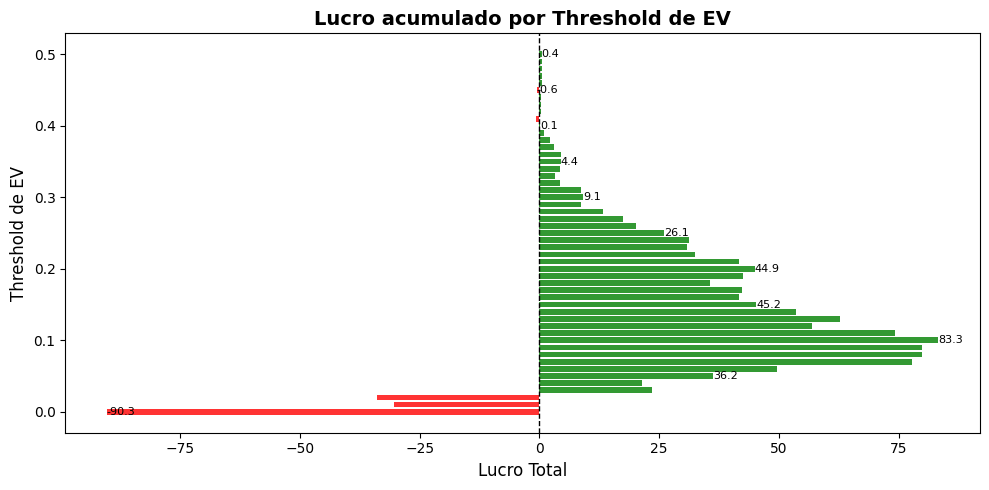

,threshold,total_profit,roi
0,0.00,-90.3000,-0.016863
1,0.01,-30.3750,-0.006373
2,0.02,-33.8375,-0.008047
3,0.03,23.4250,0.006367
4,0.04,21.3125,0.006660
5,0.05,36.2000,0.013207
6,0.06,49.6625,0.020693
7,0.07,77.8500,0.037682
8,0.08,79.8250,0.045124
9,0.09,79.9375,0.053363


In [36]:
flags = [
    "flag_u5_below_u50",
    "flag_u5_above_u50",
    "flag_u5_same_result",
    "flag_u5_below_u50_std",
    "flag_u5_above_u50_std",
]

flags_subset = [
    "flag_u5_below_u50",
    "flag_u5_above_u50",
]

# filtrar quando pelo menos uma dessas flags = 1
df_flags = tester.df[tester.df[flags_subset].any(axis=1)].copy()

# rodar backtest
tester_flag_df = Backtester(df=df_flags, y_pred=df_flags['pred'])
tester_flag_df.make_backtest()
tester_flag_df.plot_ev_ts()

tester_flag_df.resultados


In [38]:
df_flags.to_excel('df_flags.xlsx', index=False)

### Salvar objetos do Modelo

In [13]:
# Salvar Modelo Final
# X_full = np.concatenate([X, X_test], axis=0)
# y_full = np.concatenate([y, y_test], axis=0)

# final_model = xgb.XGBRegressor(**study.best_params)
# final_model.fit(X_full, y_full)
# final_model.save_model("model_22614.json")


# joblib.dump(scaler, "scaler_22614.pkl")

# print("✅ Modelo e scaler salvos com sucesso!")
